In [2]:
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import RobustScaler
import sys
sys.path.append(r"D:\HopeAI\Assignments\MyModules")
from data_analysis_utils import Preprocessing
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


sns.set_theme('notebook')


In [3]:
# dataset = pd.read_csv(r"D:\HopeAI\Assignments\ML and DS Capstone\2. Data Preprocessing\PreStockFeatures.csv")
filename=r'D:\HopeAI\Assignments\ML and DS Capstone\2. Data Preprocessing\pre_dataset.pkl'
dataset = pickle.load( open(filename,'rb'))

quan, _ = Preprocessing.quanQual(dataset)



In [4]:
dataset


,Stock,Sector,Industry,Market Cap,Year,Total_Annual_Return,Avg_Monthly_Return,Std_Monthly_Return,Max_Drawdown,Std_Daily_Return,Pos_Days_Pct,Neg_Days_Pct,Avg_Daily_TR,Max_Daily_TR,Avg_Volume,Volume_Spike_Pct,12M_Momentum,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
0,ADANIENT,Energy,Thermal Coal,2994291081216,2014,84.785613,7.637515,14.186042,22.867706,3.010790,52.674897,46.090535,2.352871,13.486429,1.861417e+07,8.196721,107.917632,63.636364,1.598832,0.426155
1,ADANIENT,Energy,Thermal Coal,2994291081216,2015,-37.685498,-3.887377,19.560876,68.997003,4.156785,45.714286,52.653061,3.742656,239.273886,1.120364e+07,7.317073,-51.324566,54.545455,1.850348,0.457929
2,ADANIENT,Energy,Thermal Coal,2994291081216,2016,-14.119856,1.611336,15.492383,34.794663,2.639648,53.469388,45.306122,1.581010,4.432787,6.074467e+06,6.097561,6.215522,54.545455,1.649825,0.597262
3,ADANIENT,Energy,Thermal Coal,2994291081216,2017,117.329561,6.434280,8.526439,28.780005,3.281672,56.680162,42.510121,2.889061,19.576553,1.295658e+07,8.064516,91.893377,81.818182,1.912510,0.332076
4,ADANIENT,Energy,Thermal Coal,2994291081216,2018,78.500944,5.578514,26.632411,43.633455,3.637141,54.693878,45.306122,6.293391,30.900989,1.475299e+07,11.382114,39.024769,36.363636,2.142941,0.478182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,WIPRO,Technology,Information Technology Services,2532097654784,2020,56.564122,5.078310,11.196238,36.623083,2.500823,52.000000,47.200000,3.742075,16.643016,2.239159e+07,9.163347,63.112320,63.636364,0.670407,0.529060
498,WIPRO,Technology,Information Technology Services,2532097654784,2021,84.735387,5.200053,6.752821,12.734524,1.763293,57.085020,42.914980,6.545712,21.253327,2.143325e+07,10.080645,71.177270,72.727273,0.849918,0.476230
499,WIPRO,Technology,Information Technology Services,2532097654784,2022,-44.808074,-3.105960,6.336069,47.492937,1.706648,47.368421,52.631579,4.864650,17.585685,1.479087e+07,3.629032,-30.838344,27.272727,1.083736,0.691712
500,WIPRO,Technology,Information Technology Services,2532097654784,2023,20.203754,1.701905,6.272716,14.238744,1.237919,48.360656,51.229508,3.161690,15.496817,1.015820e+07,6.938776,18.164716,54.545455,1.108324,0.554158


## Remove Highly Correlated Features

In [5]:
data_corr=dataset[quan].corr()
data_corr.corr()


,Market Cap,Year,Total_Annual_Return,Avg_Monthly_Return,Std_Monthly_Return,Max_Drawdown,Std_Daily_Return,Pos_Days_Pct,Neg_Days_Pct,Avg_Daily_TR,Max_Daily_TR,Avg_Volume,Volume_Spike_Pct,12M_Momentum,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
Market Cap,1.000000,-0.002218,-0.143281,-0.166544,-0.422653,-0.229058,-0.414698,0.020242,-0.007426,-0.139825,-0.195996,0.118863,-0.618654,-0.150976,-0.060576,-0.018309,0.350812
Year,-0.002218,1.000000,-0.105726,-0.128989,-0.337147,-0.193494,-0.378383,0.116904,-0.081952,0.496537,0.448584,-0.168889,-0.264041,-0.128521,-0.017828,-0.265959,0.046146
Total_Annual_Return,-0.143281,-0.105726,1.000000,0.992723,-0.101593,-0.701351,-0.209109,0.831580,-0.848322,-0.146443,-0.172960,-0.147818,0.364464,0.997865,0.933641,-0.241928,-0.486663
Avg_Monthly_Return,-0.166544,-0.128989,0.992723,1.000000,-0.008146,-0.633706,-0.120357,0.830965,-0.849714,-0.188334,-0.205372,-0.086395,0.364278,0.995086,0.927183,-0.168683,-0.433274
Std_Monthly_Return,-0.422653,-0.337147,-0.101593,-0.008146,1.000000,0.768704,0.972715,-0.085491,0.065153,-0.339249,-0.225930,0.488480,0.235508,-0.086797,-0.253881,0.639464,0.321551
Max_Drawdown,-0.229058,-0.193494,-0.701351,-0.633706,0.768704,1.000000,0.835350,-0.580993,0.576615,-0.159047,-0.058896,0.437982,-0.060709,-0.689640,-0.759226,0.616898,0.536996
Std_Daily_Return,-0.414698,-0.378383,-0.209109,-0.120357,0.972715,0.835350,1.000000,-0.206269,0.185407,-0.352900,-0.231944,0.501685,0.203638,-0.191603,-0.344102,0.720338,0.389495
Pos_Days_Pct,0.020242,0.116904,0.831580,0.830965,-0.085491,-0.580993,-0.206269,1.000000,-0.998873,-0.048940,-0.068615,-0.042203,0.101980,0.809837,0.839881,-0.205069,-0.258075
Neg_Days_Pct,-0.007426,-0.081952,-0.848322,-0.849714,0.065153,0.576615,0.185407,-0.998873,1.000000,0.084470,0.102330,0.023381,-0.124909,-0.828249,-0.850792,0.191929,0.267820
Avg_Daily_TR,-0.139825,0.496537,-0.146443,-0.188334,-0.339249,-0.159047,-0.352900,-0.048940,0.084470,1.000000,0.988716,-0.644692,-0.126177,-0.165946,-0.083402,-0.317326,-0.082233


In [6]:

corr_matrix = dataset[quan].corr().abs()  # Absolute correlations
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop with correlation > 0.75
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.75)]

print("Features to remove:", to_drop)


Features to remove: ['Avg_Monthly_Return', 'Std_Daily_Return', 'Neg_Days_Pct', 'Max_Daily_TR', '12M_Momentum']


## Remove the Unnecessary Columns

In [7]:
dataset_reduced = dataset.drop(columns=to_drop)
dataset_reduced.columns


Index(['Stock', 'Sector', 'Industry', 'Market Cap', 'Year',
       'Total_Annual_Return', 'Std_Monthly_Return', 'Max_Drawdown',
       'Pos_Days_Pct', 'Avg_Daily_TR', 'Avg_Volume', 'Volume_Spike_Pct',
       'Months_Pos_Pct', 'Beta_vs_NIFTY', 'Corr_with_NIFTY'],
      dtype='object')

In [8]:
filename="dataset_reduced.pkl"
pickle.dump(dataset_reduced, open(filename,'wb'))

cols_to_drop = ['Stock', 'Sector', 'Industry', 'Year']
dataset_unscaled = dataset_reduced.drop(cols_to_drop, axis=1)
filename="dataset_unscaled.pkl"
pickle.dump(dataset_unscaled, open(filename,'wb'))


## Scaling numeric columns and Creating dummies for categorical columns

In [9]:
# Standardize numeric features

scaler = RobustScaler()
dataset_scaled = scaler.fit_transform(dataset_unscaled)
filename="scaler.pkl"
pickle.dump(scaler, open(filename,'wb'))
dataset_scaled


array([[-0.01585248,  1.78455141,  2.00138868, ...,  0.5       ,
         1.20055983, -0.34570011],
       [-0.01585248, -1.3764908 ,  3.5835421 , ...,  0.        ,
         1.67576192, -0.20341348],
       [-0.01585248, -0.76824948,  2.38592752, ...,  0.        ,
         1.29690244,  0.42052859],
       ...,
       [-0.17661286, -1.56032813, -0.30935448, ..., -1.5       ,
         0.22735895,  0.84348681],
       [-0.17661286,  0.1176605 , -0.32800309, ...,  0.        ,
         0.27381386,  0.22750579],
       [-0.17661286,  0.30776083, -0.14732615, ...,  1.        ,
         0.17744486,  0.13139078]], shape=(484, 11))

## Dimensionality Reduction - PCA

5 components are required to explain 85.36% variance of data


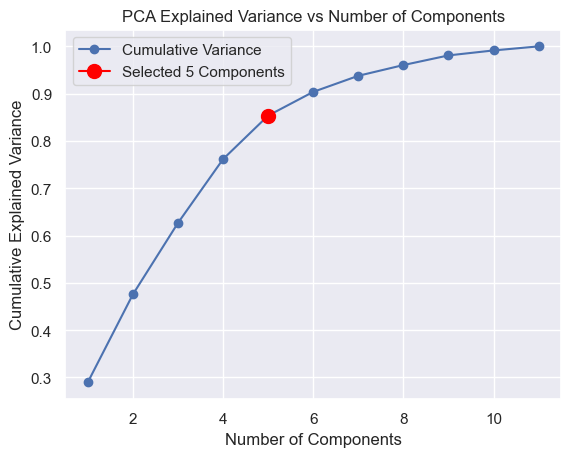

In [10]:
pca = PCA().fit(dataset_scaled)
pca_exp_var = pca.explained_variance_ratio_
exp_cum = pca_exp_var.cumsum()
# Choose minimal n_components where cumulative variance >= threshold
threshold = 0.80
pca_comp = next(i for i, total_var in enumerate(exp_cum, start=1) if total_var >= threshold)
print(f'{pca_comp} components are required to explain {exp_cum[pca_comp-1]*100:.2f}% variance of data')

plt.plot(range(1, len(pca_exp_var) + 1), 
         exp_cum, marker='o', label='Cumulative Variance')
# Highlight the chosen component with a red marker
plt.plot(pca_comp, exp_cum[pca_comp - 1], marker='o', color='red', markersize=10, label=f'Selected {pca_comp} Components')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance vs Number of Components')
plt.legend()
plt.show()


In [13]:

pca = PCA(n_components = pca_comp)
X = pca.fit_transform(dataset_scaled)
filename="pca.pkl"
pickle.dump(pca, open(filename,'wb'))


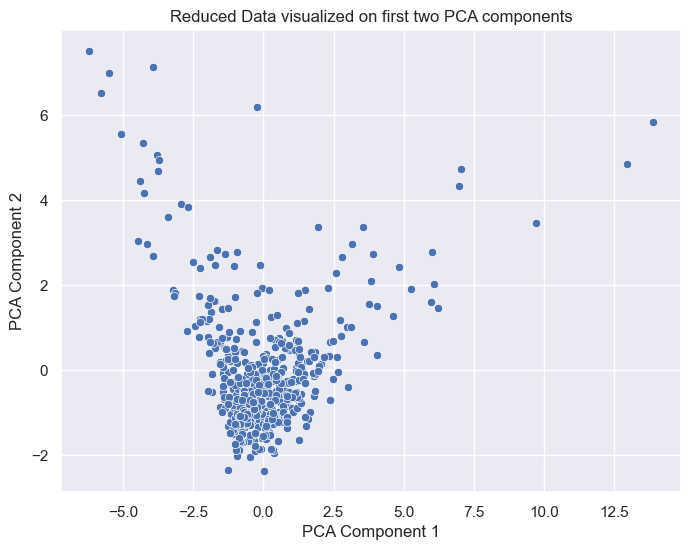

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X[:, 0], y=X[:, 1])
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Reduced Data visualized on first two PCA components')
plt.show()
